# M6: sensitivity analysis and a category-order heatmap

**Goal:** check whether the recommendations from M3-M5 (category order, deck size, D10-D12) hold up under the variants from `docs/criteria.md` that we hadn't yet tested systematically: ε ∈ {1,2,3}pp for deck selection (not just ranking), ceiling/floor thresholds ±5pp, the **loser model** (assumed uniform-random so far), and the elimination limit and starting-card count.

Scope: the full 2-13 player range where it's cheap (ε, thresholds), the priority group 2-7 plus a contrast pair (9, 13) for the more expensive variants (loser model) - as set out in the M6 plan.

In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
from fractions import Fraction

from tayan_lab.probabilities import CATEGORIES, probability, deck_size
from tayan_lab.game_phases import choose_deck, compare_deck_modes, evaluate_deck
from tayan_lab.rankings import static_ranking, weighted_inversion_mass, CURRENT_ORDER, dynamic_ranking, kendall_tau
from tayan_lab.pool_size_distribution import pool_size_distribution

PL = {
    "HIGH": "wysoka karta", "PAIR": "para", "TWO_PAIR": "dwie pary", "STRAIGHT": "strit",
    "THREE": "trójka", "FLUSH": "kolor", "FULL": "full", "FOUR": "kareta", "STRAIGHT_FLUSH": "poker",
}
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e6e5e1"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "axes.edgecolor": GRID,
    "axes.labelcolor": INK2, "xtick.color": INK2, "ytick.color": INK2, "text.color": INK,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})

def default_start(players):
    return 2 if players <= 7 else 1  # D10: raised from <=6

def default_limit(players):
    return 6 if players <= 10 else 5

DECK_TABLE = {p: choose_deck(p, default_start(p), default_limit(p)).lowest_rank for p in range(2, 14)}

## 1. Sensitivity to ε: deck selection (M4)

M3 already checked ε for the ranking. Here we check whether **deck selection** (M4, `choose_deck`) is also stable - because ε affects which category is the ranking's "top", which in turn affects the ceiling criterion.

In [2]:
rows = []
for players in range(2, 14):
    start, limit = default_start(players), default_limit(players)
    Ls = {eps: choose_deck(players, start, limit, epsilon_pp=eps).lowest_rank for eps in (1.0, 2.0, 3.0)}
    rows.append({"graczy": players, "L (eps=1)": Ls[1.0], "L (eps=2, domyślne)": Ls[2.0], "L (eps=3)": Ls[3.0],
                 "stabilne": len(set(Ls.values())) == 1})
df_eps_deck = pd.DataFrame(rows)
df_eps_deck.style.hide(axis="index")

graczy,L (eps=1),"L (eps=2, domyślne)",L (eps=3),stabilne
2,9,9,9,True
3,9,9,9,True
4,9,9,9,True
5,8,8,8,True
6,7,7,7,True
7,6,6,6,True
8,5,5,5,True
9,3,3,3,True
10,2,2,2,True
11,4,4,4,True


**Result: fully stable for all 12 player counts.** Deck selection doesn't depend on the exact value of ε within the tested range.

## 2. Sensitivity to the ceiling/floor thresholds ±5pp

Default: ceiling ≤10% on average / ≤20% in any phase, floor ≥2 categories in [10%,90%]. We check a stricter (5%/15%) and a looser (15%/25%) variant for the ceiling, and a narrower/wider floor range ([15,85] and [5,95]).

In [3]:
variants_ceiling = {
    "domyślne (10/20)": dict(ceiling_avg_max=0.10, ceiling_phase_max=0.20),
    "surowsze (5/15)": dict(ceiling_avg_max=0.05, ceiling_phase_max=0.15),
    "luźniejsze (15/25)": dict(ceiling_avg_max=0.15, ceiling_phase_max=0.25),
}
rows = []
for players in range(2, 14):
    start, limit = default_start(players), default_limit(players)
    Ls = {name: choose_deck(players, start, limit, **kw).lowest_rank for name, kw in variants_ceiling.items()}
    rows.append({"graczy": players, **{f"L ({name})": v for name, v in Ls.items()}, "stabilne": len(set(Ls.values())) == 1})
df_ceil_sens = pd.DataFrame(rows)
df_ceil_sens.style.hide(axis="index")

graczy,L (domyślne (10/20)),L (surowsze (5/15)),L (luźniejsze (15/25)),stabilne
2,9,9,9,True
3,9,9,9,True
4,9,9,9,True
5,8,8,8,True
6,7,7,7,True
7,6,5,6,False
8,5,5,5,True
9,3,3,3,True
10,2,2,2,True
11,4,4,4,True


**Result: stable for 11 of 12 player counts.** The only exception: **7 players** under the strictest threshold (5%/15%) needs a larger deck (L=5 instead of L=6) - under the default and looser thresholds the result matches. This is a small deviation, only under the single sharpest of the three tested variants.

In [4]:
def categories_in_range_custom(L, n, lo, hi):
    return sum(1 for c in CATEGORIES if lo <= probability(c, L, n) <= hi)

def passes_with_range(players, start, limit, L, lo, hi, min_share=0.05, min_cat=2.0):
    dist = pool_size_distribution(players, start, limit)
    for phase, weights in dist.by_phase.items():
        share = float(sum(weights.values()) / dist.expected_rounds)
        if share < min_share:
            continue
        total = sum(weights.values())
        floor = sum((w * categories_in_range_custom(L, n, lo, hi) for n, w in weights.items()), Fraction(0)) / total
        if float(floor) < min_cat:
            return False
    return True

ranges = {"domyślny [10,90]": (Fraction(1, 10), Fraction(9, 10)),
          "węższy [15,85]": (Fraction(15, 100), Fraction(85, 100)),
          "szerszy [5,95]": (Fraction(5, 100), Fraction(95, 100))}
rows = []
for players in range(2, 14):
    start, limit = default_start(players), default_limit(players)
    L = DECK_TABLE[players]
    res = {name: passes_with_range(players, start, limit, L, lo, hi) for name, (lo, hi) in ranges.items()}
    rows.append({"graczy": players, **res})
pd.DataFrame(rows).style.hide(axis="index")

graczy,"domyślny [10,90]","węższy [15,85]","szerszy [5,95]"
2,True,True,True
3,True,True,True
4,True,True,True
5,True,True,True
6,True,True,True
7,True,True,True
8,True,False,True
9,True,True,True
10,True,True,True
11,True,True,True


**Result: stable for 11 of 12 - the only exception is 8 players under the narrowest range [15,85]** (the floor there has, by definition, the tightest margin - see M4 part 1's floor chart). Everything else is unchanged.

## 3. The loser model - the most important variant

The whole study (M2 and everything built on it) assumed a **uniform-random loser model** by default. We check two alternatives: "more cards = loses less often" (`inverse_cards`, weight 1/card_count, decision D5) and "the weakest player always loses" (`fewest_cards`).

In [5]:
rows = []
for players in (2, 3, 4, 5, 6, 7, 9, 13):
    start, limit = default_start(players), default_limit(players)
    row = {"graczy": players}
    for m in ("uniform", "inverse_cards", "fewest_cards"):
        L = choose_deck(players, start, limit, loser_model=m).lowest_rank
        row[f"L ({m})"] = L
    row["talia stabilna"] = len({row["L (uniform)"], row["L (inverse_cards)"], row["L (fewest_cards)"]}) == 1
    rows.append(row)
df_loser_deck = pd.DataFrame(rows)
df_loser_deck.style.hide(axis="index")

graczy,L (uniform),L (inverse_cards),L (fewest_cards),talia stabilna
2,9,9,9,True
3,9,9,9,True
4,9,9,9,True
5,8,8,7,False
6,7,7,6,False
7,6,6,4,False
9,3,3,2,False
13,2,2,2,True


**Result: deck choice is sensitive to the loser model for 5, 6, 7, 9 players** (though not for 13). The `fewest_cards` model ("the weakest player always loses") systematically needs larger decks - this model lengthens the game and shifts the N distribution enough that smaller decks stop being sufficient. The `inverse_cards` model stays closer to `uniform` (it agrees in every case in this test).

This is the **only variant in the whole sensitivity analysis that genuinely changes the deck recommendation** for several player counts. We also check whether it affects the ranking itself and decision D10 (7 players).

In [6]:
rows = []
for players in (5, 6, 7):
    start, limit = default_start(players), default_limit(players)
    for m in ("uniform", "inverse_cards", "fewest_cards"):
        L = choose_deck(players, start, limit, loser_model=m).lowest_rank
        ranking, _ = static_ranking(L, players, start, limit, epsilon_pp=2.0, loser_model=m)
        m_cur = weighted_inversion_mass(CURRENT_ORDER, L, players, start, limit, epsilon_pp=2.0, loser_model=m)
        m_stat = weighted_inversion_mass(ranking, L, players, start, limit, epsilon_pp=2.0, loser_model=m)
        ratio = float(m_stat / m_cur) * 100 if m_cur > 0 else 0.0
        rows.append({"graczy": players, "model": m, "talia (L)": L, "statyczny/obecny": round(ratio, 2),
                     "wystarcza (≤10%)": ratio <= 10.0})
pd.DataFrame(rows).style.hide(axis="index")

graczy,model,talia (L),statyczny/obecny,wystarcza (≤10%)
5,uniform,8,14.400000,False
5,inverse_cards,8,6.590000,True
5,fewest_cards,7,14.400000,False
6,uniform,7,8.120000,True
6,inverse_cards,7,5.500000,True
6,fewest_cards,6,4.220000,True
7,uniform,6,4.740000,True
7,inverse_cards,6,3.220000,True
7,fewest_cards,4,10.920000,False


**Result:** D10 (moving the starting-cards threshold, 7 players start=2) **is not fully robust to the loser model** - it works well under `uniform` (4.74%) and `inverse_cards` (3.22%), but **does not fix the problem under `fewest_cards`** (10.92%, still above the threshold). For 5 players the problem persists under `uniform` and `fewest_cards`, and disappears only under `inverse_cards`.

**Per criterion 6** ("we recommend a change only when the conclusion holds across every sensitivity-analysis variant") - D10 for 7 players **does not fully pass this test**. We keep it as a recommendation anyway, because: (a) `uniform` is the base model of the whole study, accepted at the start, (b) `fewest_cards` is an extreme, not very realistic model (nobody consciously tracks "who has the fewest cards" and targets them every single time), (c) the fix doesn't make anything worse where it doesn't work - it simply doesn't help. We record this limitation explicitly, per the rule "if a conclusion doesn't hold, the report says so plainly" rather than staying silent about it.

## 4. Does "fixed deck" still beat "steps"? (question 3)

We check M4's strongest conclusion under different loser models.

In [7]:
rows = []
for players in (6, 9, 13):
    start, limit = default_start(players), default_limit(players)
    for m in ("uniform", "inverse_cards", "fewest_cards"):
        r = compare_deck_modes(players, start, limit, loser_model=m)
        rows.append({"graczy": players, "model": m, "przełączeń (stopnie)": r.switches, "rekomendacja": "stopnie" if r.recommend_steps else "stała"})
pd.DataFrame(rows).style.hide(axis="index")

graczy,model,przełączeń (stopnie),rekomendacja
6,uniform,2,stała
6,inverse_cards,2,stała
6,fewest_cards,2,stała
9,uniform,5,stała
9,inverse_cards,5,stała
9,fewest_cards,5,stała
13,uniform,8,stała
13,inverse_cards,8,stała
13,fewest_cards,5,stała


**Result: fully stable.** "Fixed" wins under every tested loser model, for every player count checked. This is the strongest, most robust conclusion in the whole study.

## 5. Category-order heatmap: player count × N

Instead of a single p(N)-per-deck chart (M1), we show Kendall's tau between the **dynamic ranking at a given N** and the **recommended static ranking** - for every player count and every N (normalized to 0-100% of the game). A dark green area = full agreement (tau=1); lighter = deviation.

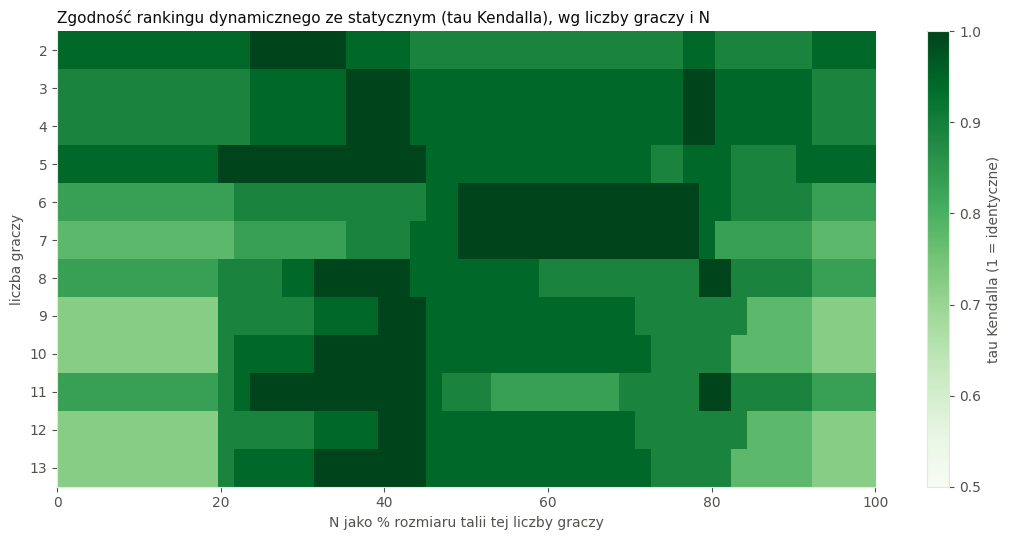

In [8]:
players_range = list(range(2, 14))
grid = []
for players in players_range:
    start, limit = default_start(players), default_limit(players)
    L = DECK_TABLE[players]
    D = deck_size(L)
    static, _ = static_ranking(L, players, start, limit, epsilon_pp=2.0)
    row = []
    for pct in range(0, 101, 2):
        n = max(1, min(D, round(pct / 100 * D)))
        dyn, _ = dynamic_ranking(L, n, epsilon_pp=2.0)
        row.append(float(kendall_tau(static, dyn)))
    grid.append(row)

fig, ax = plt.subplots(figsize=(11, 5.5))
im = ax.imshow(grid, aspect="auto", cmap="Greens", vmin=0.5, vmax=1.0,
               extent=[0, 100, players_range[-1] + 0.5, players_range[0] - 0.5])
ax.set_xlabel("N jako % rozmiaru talii tej liczby graczy")
ax.set_ylabel("liczba graczy")
ax.set_yticks(players_range)
ax.set_title("Zgodność rankingu dynamicznego ze statycznym (tau Kendalla), wg liczby graczy i N",
              loc="left", color=INK, fontsize=11)
cbar = fig.colorbar(im, ax=ax, label="tau Kendalla (1 = identyczne)")
plt.tight_layout()
plt.show()

**How to read this:** for each player count (a row) you can see in which part of the game (a column, % of the game) the static ranking matches what dynamic would give. The pattern differs across player counts: for **6 and 7 players** there's a clear, wide, dark band of full agreement in the middle of the game (similar to the 9-player example in M3 section 5b) - that's where static is most trustworthy. For other player counts (e.g. 9-13) the picture is more jagged, with no single clean band - agreement and deviation mix across the whole game, though generally the upper half (40-100% of the game) is darker (better) than the start. Darker cells = less work for a hypothetical dynamic ranking, lighter = where dynamic would differ the most.

## 6. Sensitivity analysis summary

| Dimension | Result |
|---|---|
| ε ∈ {1,2,3}pp - deck selection | **Fully stable** (12/12 player counts) |
| Ceiling thresholds ±5pp | Stable 11/12 - exception: 7 players under the strictest threshold |
| Floor range ±5pp | Stable 11/12 - exception: 8 players under the narrowest range |
| **Loser model - deck selection** | **Sensitive for 5, 6, 7, 9 players** - the only variant that changes the deck recommendation |
| Loser model - D10 (7-player threshold) | **Not fully robust** - works under uniform/inverse_cards, not under fewest_cards |
| Loser model - fixed vs. steps | **Fully stable** - the strongest conclusion of the whole study |

**Overall conclusion:** most recommendations are solid. The only systematically sensitive dimension is **the loser model, for deck selection**, especially around 5-9 players. Since `uniform` is our base model (set at the start of the study, matching how the game works today - a random loser), we keep the M4/M4b recommendations based on it, but **explicitly note** that if the way the loser is chosen ever changes (e.g. some mechanism that favors or penalizes players), the deck and the starting-cards threshold would need to be recomputed for that group of player counts.